## Import Libraries

In [ ]:
%pip install pandas --quiet
%pip install plotly --quiet
%pip install --upgrade nbformat --quiet
%pip install seaborn --quiet
%pip install matplotlib --quiet
%pip install scikit-learn --quiet

import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Data Preparation

### Reading Raw Dataset

In [3]:
df = pd.read_csv("../data/clackamas_river.csv")

### Feature Selection and Renaming

In [4]:
columns_to_keep = ["datetime", "00010_Mean", "00300_Mean", "00400_Median", "63680_Median"]
df_selected = df[columns_to_keep]

rename_dict = {
    "00010_Mean": "Temperature",
    "00300_Mean": "Dissolved Oxygen",
    "00400_Median": "pH",
    "63680_Median": "Turbidity"
}
df_renamed = df_selected.rename(columns=rename_dict)

### Datetime Processing and Filtering

In [5]:
df_renamed['datetime'] = pd.to_datetime(df_renamed['datetime'], errors='coerce', format='mixed', utc=True)

df_renamed = df_renamed.dropna(subset=['datetime'])

df_renamed['datetime'] = df_renamed['datetime'].dt.tz_localize(None)

df_final = df_renamed[(df_renamed['datetime'].dt.year >= 2019) & (df_renamed['datetime'].dt.year <= 2023)]

output_filename = "../data/clackamas_river_selected_column.csv"
df_final.to_csv(output_filename, index=False)

## Data Understanding

In [6]:
df = pd.read_csv('../data/clackamas_river_selected_column.csv', parse_dates=['datetime'])

### Data Structure and Missing Values Check

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          1773 non-null   datetime64[ns]
 1   Temperature       1771 non-null   float64       
 2   Dissolved Oxygen  1771 non-null   float64       
 3   pH                1749 non-null   float64       
 4   Turbidity         1771 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 69.4 KB


### Descriptive Statistics

In [8]:
df.describe()

,datetime,Temperature,Dissolved Oxygen,pH,Turbidity
count,1773,1771.000000,1771.000000,1749.000000,1771.000000
mean,2021-07-09 21:47:36.852791808,11.387973,11.153586,7.555517,2.385658
min,2019-01-01 00:00:00,2.600000,8.200000,7.000000,0.100000
25%,2020-04-12 00:00:00,6.500000,9.900000,7.400000,0.800000
50%,2021-07-16 00:00:00,9.600000,11.500000,7.500000,1.400000
75%,2022-10-08 00:00:00,16.200000,12.400000,7.700000,2.400000
max,2023-12-31 00:00:00,23.900000,13.700000,8.400000,91.600000
std,NaN,5.665086,1.435928,0.251766,4.579043


## Exploratory Data Analysis (EDA)

### Distribution and Outlier Visualization

#### Datetime

In [9]:
fig_dt = px.histogram(
    df, 
    x="datetime", 
    marginal="box", 
    title="Distribusi Waktu dan Boxplot: datetime",
    color_discrete_sequence=['#1f77b4']
)
fig_dt.update_layout(yaxis_title="Frekuensi")
fig_dt.show()

Interval pengambilan sampel berjalan secara konstan dan berkala. Adanya penurunan frekuensi (celah/gap) pada periode tertentu mengindikasikan terjadinya kehilangan data (missing values) atau interupsi pada proses akuisisi data, yang memerlukan penanganan seperti interpolasi sebelum pemodelan.

#### Temperature

In [10]:
fig_temp = px.histogram(
    df, 
    x="Temperature", 
    marginal="box", 
    title="Distribusi Data dan Boxplot: Temperature",
    color_discrete_sequence=['#ff7f0e']
)
fig_temp.update_layout(yaxis_title="Frekuensi")
fig_temp.show()

#### Dissolved Oxygen

In [11]:
fig_do = px.histogram(
    df, 
    x="Dissolved Oxygen", 
    marginal="box", 
    title="Distribusi Data dan Boxplot: Dissolved Oxygen",
    color_discrete_sequence=['#2ca02c']
)
fig_do.update_layout(yaxis_title="Frekuensi")
fig_do.show()

#### pH

In [12]:
fig_ph = px.histogram(
    df, 
    x="pH", 
    marginal="box", 
    title="Distribusi Data dan Boxplot: pH",
    color_discrete_sequence=['#9467bd']
)
fig_ph.update_layout(yaxis_title="Frekuensi")
fig_ph.show()

#### Turbidity

In [13]:
fig_turb = px.histogram(
    df, 
    x="Turbidity", 
    marginal="box", 
    title="Distribusi Data dan Boxplot: Turbidity",
    color_discrete_sequence=['#d62728']
)
fig_turb.update_layout(yaxis_title="Frekuensi")
fig_turb.show()

### Time Series Analysis

In [ ]:
fig = make_subplots(
    rows=4, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Temperature", "Dissolved Oxygen", "pH", "Turbidity")
)

fig.add_trace(go.Scatter(x=df['datetime'], y=df['Temperature'], mode='lines', name='Temperature', line=dict(color='#ff7f0e')), row=1, col=1)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['Dissolved Oxygen'], mode='lines', name='Dissolved Oxygen', line=dict(color='#2ca02c')), row=2, col=1)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['pH'], mode='lines', name='pH', line=dict(color='#9467bd')), row=3, col=1)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['Turbidity'], mode='lines', name='Turbidity', line=dict(color='#d62728')), row=4, col=1)

fig.update_layout(
    title="Time-Series Kualitas Air Sungai Clackamas (2019 - 2023)",
    height=800,
    width=600,
    showlegend=False,
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

## Data Cleaning

### Handling Missing Values

In [15]:
df = df.sort_values(by='datetime').reset_index(drop=True)

print("Jumlah Null sebelum cleaning:")
print(df.isnull().sum())
print("-" * 30)

df['Temperature'] = df['Temperature'].interpolate(method='linear', limit_direction='both')
df['Dissolved Oxygen'] = df['Dissolved Oxygen'].interpolate(method='linear', limit_direction='both')
df['pH'] = df['pH'].interpolate(method='linear', limit_direction='both')
df['Turbidity'] = df['Turbidity'].interpolate(method='linear', limit_direction='both')

print("Jumlah Null setelah cleaning:")
print(df.isnull().sum())

Jumlah Null sebelum cleaning:
datetime             0
Temperature          2
Dissolved Oxygen     2
pH                  24
Turbidity            2
dtype: int64
------------------------------
Jumlah Null setelah cleaning:
datetime            0
Temperature         0
Dissolved Oxygen    0
pH                  0
Turbidity           0
dtype: int64


### Feature Scaling

In [16]:
numeric_cols = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Data setelah dilakukan Scaling (5 baris pertama):")
print(df_scaled.head())

print("\nStatistik setelah Scaling:")
print(df_scaled[numeric_cols].describe().round(2))

Data setelah dilakukan Scaling (5 baris pertama):
    datetime  Temperature  Dissolved Oxygen       pH  Turbidity
0 2019-01-01    -1.040735          1.078352 -1.01802   0.178417
1 2019-01-02    -1.111347          1.148003 -1.01802   0.069140
2 2019-01-03    -1.058388          1.078352 -1.01802   0.025430
3 2019-01-04    -1.058388          1.008701 -1.01802   0.069140
4 2019-01-05    -1.093694          0.939050 -1.01802  -0.018281

Statistik setelah Scaling:
       Temperature  Dissolved Oxygen       pH  Turbidity
count      1773.00           1773.00  1773.00    1773.00
mean          0.00              0.00     0.00       0.00
std           1.00              1.00     1.00       1.00
min          -1.55             -2.06    -2.22      -0.50
25%          -0.86             -0.87    -0.62      -0.35
50%          -0.32              0.24    -0.22      -0.21
75%           0.85              0.87     0.58       0.00
max           2.21              1.77     3.38      19.50


In [17]:
df.to_csv("../data/clackamas_river_cleaned_ready.csv", index=False)

## Feature Correlation Analysis

### Correlation Heatmap

In [18]:
numeric_cols = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']
corr_matrix = df[numeric_cols].corr()

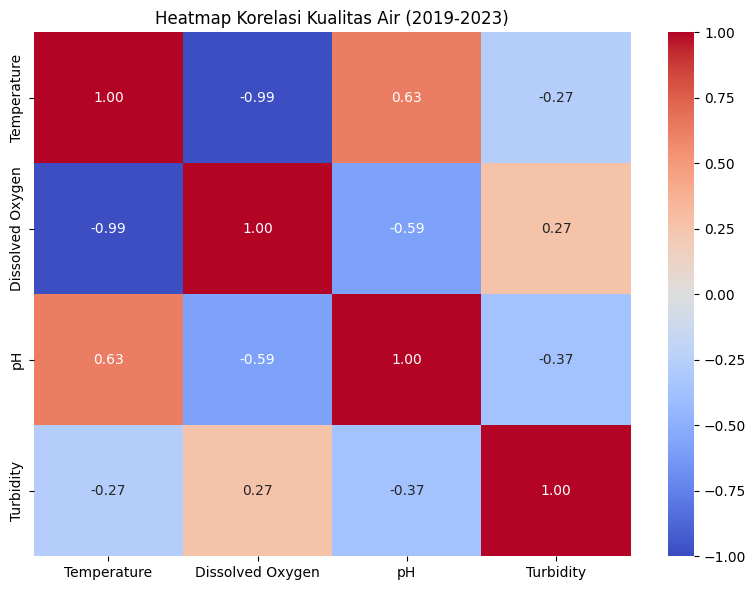

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Kualitas Air (2019-2023)')
plt.tight_layout()

## Anomaly Detection

### Isolation Forest

#### Threshold Setup and Model Selection

In [21]:
model_if = IsolationForest(contamination='auto', random_state=42)

#### Model Training and Evaluation

In [22]:
numeric_cols = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']

model_if.fit(df_scaled[numeric_cols])

predictions = model_if.predict(df_scaled[numeric_cols])

df['Anomaly_Label'] = predictions
df['Anomaly_Label'] = df['Anomaly_Label'].map({1: 'Normal', -1: 'Anomaly'})

print("=== Hasil Deteksi Anomali ===")
print(df['Anomaly_Label'].value_counts())
print("-" * 30)

=== Hasil Deteksi Anomali ===
Anomaly_Label
Normal     1497
Anomaly     276
Name: count, dtype: int64
------------------------------


#### Anomaly Result Visualization

In [26]:
df_anomali = df[df['Anomaly_Label'] == 'Anomaly']

fig = make_subplots(
    rows=4, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Temperature", "Dissolved Oxygen", "pH", "Turbidity")
)

colors = ['#ff7f0e', '#2ca02c', '#9467bd', '#1f77b4']

for i, col in enumerate(numeric_cols, start=1):
    fig.add_trace(
        go.Scatter(x=df['datetime'], y=df[col], mode='lines', name=col, line=dict(color=colors[i-1], width=1)), 
        row=i, col=1
    )
    
    fig.add_trace(
        go.Scatter(x=df_anomali['datetime'], y=df_anomali[col], mode='markers', name=f'Anomaly ({col})', 
                   marker=dict(color='red', size=6, symbol='x')), 
        row=i, col=1
    )
fig.update_layout(
    title="Deteksi Anomali Kualitas Air - Isolation Forest (Merah = Anomali)",
    height=900,
    width=600,
    showlegend=False,
    hovermode="x unified",
    template="plotly_white"
)

fig.show()